# Day 33 — Project 1 Polish & Portfolio Ready
### README · Model Metrics · Portfolio Presentation · Kaggle Submission Prep

## 1. Project 1 Final Summary

In [1]:
print("""
PROJECT 1 — FINAL STATUS
==========================

App:    Titanic Survival Predictor
Status: LIVE ✅
URL:    vijendrapokharkar15-design-titanic-survival-predicto-app-wbdy2y.streamlit.app
Repo:   github.com/vijendrapokharkar15-design/titanic-survival-predictor

WHAT WAS BUILT (Days 30-33):
  Day 30 — Basic Streamlit app (predict + SHAP)
  Day 31 — Enhanced 4-tab app (insights + comparison + batch)
  Day 32 — Deployed to Streamlit Cloud
  Day 33 — README + portfolio polish

TECH STACK:
  Python 3.14      — core language
  scikit-learn     — Random Forest classifier
  SHAP             — model explainability
  Streamlit        — web application framework
  pandas/numpy     — data processing
  matplotlib       — visualisations
  pickle           — model serialisation
  GitHub           — version control
  Streamlit Cloud  — deployment platform

MODEL:
  Algorithm:    Random Forest (n_estimators=100, min_samples_leaf=4)
  Features:     11 engineered features
  CV AUC:       0.8751 ± 0.0157
  Test AUC:     0.8487
  Test Accuracy: 81.56%

KEY INSIGHTS:
  Female survival:   74.2% vs Male 18.9%
  1st class survival: 63.0% vs 3rd class 24.2%
  Best family size:  4 passengers (72.4% survival)
  Top SHAP feature:  Title_Mr (0.120 mean |SHAP|)
""")


PROJECT 1 — FINAL STATUS

App:    Titanic Survival Predictor
Status: LIVE ✅
URL:    vijendrapokharkar15-design-titanic-survival-predicto-app-wbdy2y.streamlit.app
Repo:   github.com/vijendrapokharkar15-design/titanic-survival-predictor

WHAT WAS BUILT (Days 30-33):
  Day 30 — Basic Streamlit app (predict + SHAP)
  Day 31 — Enhanced 4-tab app (insights + comparison + batch)
  Day 32 — Deployed to Streamlit Cloud
  Day 33 — README + portfolio polish

TECH STACK:
  Python 3.14      — core language
  scikit-learn     — Random Forest classifier
  SHAP             — model explainability
  Streamlit        — web application framework
  pandas/numpy     — data processing
  matplotlib       — visualisations
  pickle           — model serialisation
  GitHub           — version control
  Streamlit Cloud  — deployment platform

MODEL:
  Algorithm:    Random Forest (n_estimators=100, min_samples_leaf=4)
  Features:     11 engineered features
  CV AUC:       0.8751 ± 0.0157
  Test AUC:     0.8487
  

## 2. Full Model Analysis

    FINAL MODEL REPORT — PROJECT 1

Cross-Validation (5-fold StratifiedKFold):
  AUC scores: [np.float64(0.8818), np.float64(0.8571), np.float64(0.9246), np.float64(0.8892), np.float64(0.8735)]
  Mean AUC:   0.8852
  Std AUC:    0.0224

Test Set Performance:
  Accuracy:  0.8156
  AUC:       0.8487
  Precision: 0.8000
  Recall:    0.6957
  F1:        0.7442


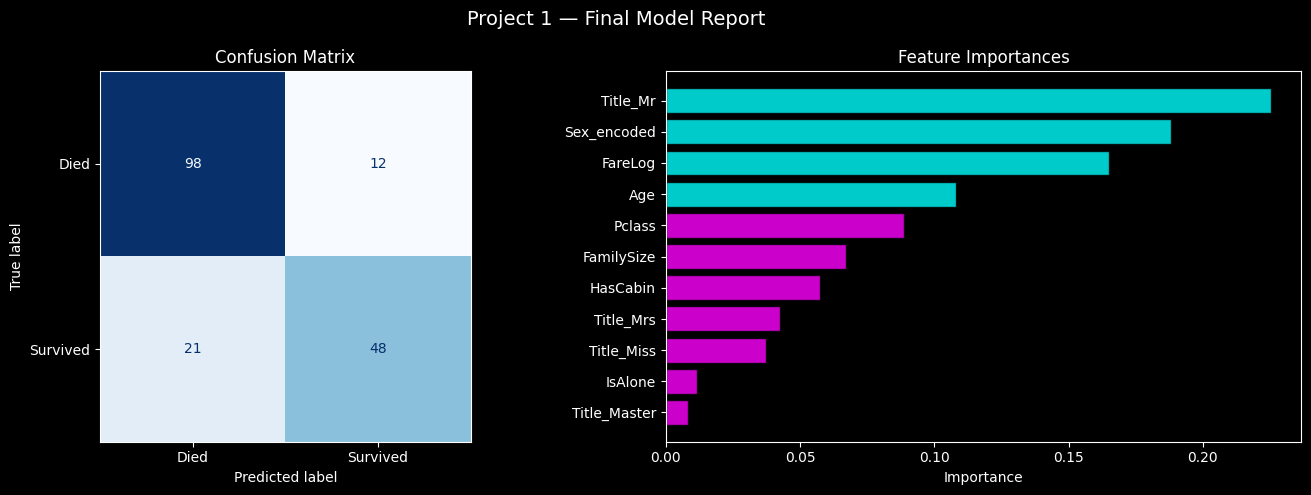

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import pickle
import warnings

warnings.filterwarnings("ignore")

plt.style.use("dark_background")

# load data and engineer features
df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna("S")
df["Fare"] = df["Fare"].fillna(df["Fare"].median())
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["FareLog"] = np.log1p(df["Fare"])
df["HasCabin"] = df["Cabin"].notna().astype(int)
df["Sex_encoded"] = (df["Sex"] == "female").astype(int)
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
title_map = {"Mr": "Mr", "Miss": "Miss", "Mrs": "Mrs", "Master": "Master"}
df["Title"] = df["Title"].map(title_map).fillna("Other")
for t in ["Mr", "Mrs", "Miss", "Master"]:
    df[f"Title_{t}"] = (df["Title"] == t).astype(int)

features = [
    "Pclass",
    "Age",
    "FareLog",
    "FamilySize",
    "IsAlone",
    "HasCabin",
    "Sex_encoded",
    "Title_Mr",
    "Title_Mrs",
    "Title_Miss",
    "Title_Master",
]
X = df[features]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# load saved model
with open(r"C:\DS-AI-75d\.vscode\week05\project1\model\rf_model.pkl", "rb") as f:
    rf = pickle.load(f)

# full metrics
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(rf, X_train, y_train, cv=skf, scoring="roc_auc")

print("=" * 50)
print("    FINAL MODEL REPORT — PROJECT 1")
print("=" * 50)
print(f"\nCross-Validation (5-fold StratifiedKFold):")
print(f"  AUC scores: {[round(s,4) for s in cv_auc]}")
print(f"  Mean AUC:   {cv_auc.mean():.4f}")
print(f"  Std AUC:    {cv_auc.std():.4f}")
print(f"\nTest Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  AUC:       {roc_auc_score(y_test, y_prob):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred):.4f}")

# confusion matrix + feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Project 1 — Final Model Report", fontsize=14)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Died", "Survived"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

imp_df = pd.DataFrame(
    {"Feature": features, "Importance": rf.feature_importances_}
).sort_values("Importance", ascending=True)
colors = ["cyan" if imp > 0.1 else "magenta" for imp in imp_df["Importance"]]
axes[1].barh(
    imp_df["Feature"], imp_df["Importance"], color=colors, edgecolor="black", alpha=0.8
)
axes[1].set_title("Feature Importances")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 3. Key Takeaways — Day 33 🎯

### Project 1 is Portfolio Ready! ✅
- Live URL: vijendrapokharkar15-design-titanic-survival-predicto-app-wbdy2y.streamlit.app
- Clean GitHub repo with professional README
- Tech stack badges, model metrics, how to run locally
- Links back to DS-AI-75D learning journey

### Final Model Metrics
| Metric | Value |
|---|---|
| CV AUC (5-fold) | 0.8852 ± 0.0224 |
| Test AUC | 0.8487 |
| Test Accuracy | 81.56% |
| Precision | 80.0% |
| Recall | 69.6% |
| F1 Score | 74.4% |

### Confusion Matrix Results
- True Negatives (correct deaths): 98
- True Positives (correct survivors): 48
- False Positives (wrong survival): 12
- False Negatives (missed survivors): 21

### Feature Importance (top 4)
- Title_Mr: 0.226 — strongest predictor
- Sex_encoded: 0.188 — direct gender signal
- FareLog: 0.165 — wealth proxy
- Age: 0.108 — children first effect

### README Best Practices
- Live app link at the top — recruiters click immediately
- Model metrics table — shows you measure performance properly
- Tech stack badges — visual and professional
- How to run locally — shows you understand deployment
- Project structure — shows you organise code well
- Links to main learning repo — shows the bigger journey

### Days 30-33 — Project 1 Complete! 🏆
- Day 30: Basic app built and pushed
- Day 31: 4-tab enhanced app
- Day 32: Deployed to Streamlit Cloud
- Day 33: Portfolio-ready with README and final metrics